# Practical worksheet: DCGAN for training + inference (MNIST + CIFAR-10)

## Learning focus
1. Build a **DCGAN** (convolutional Generator + Discriminator) with BCE adversarial loss.
2. Train DCGAN on **MNIST** (resized to 32x32) and **CIFAR-10**.
3. Save checkpoints and reload generator for **inference**.
4. Render a simple latent-space interpolation to inspect continuity.

## Notebook setup
The next cells install/import dependencies, define reproducibility/device settings, and build reusable data loaders.

In [1]:
%pip install -q tqdm
%matplotlib inline

import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

Note: you may need to restart the kernel to use updated packages.


Define reproducibility and device selection (`cuda`, `mps`, `cpu`).

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device('mps')
    return torch.device('cpu')


set_seed(42)
device = get_device()
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print('Device:', device)

Device: cuda


Build loaders for MNIST and CIFAR-10 normalized to `[-1, 1]`.

Note: MNIST is resized to **32x32** so we can reuse the same DCGAN architecture.

In [3]:
def build_loaders(
    dataset_name='mnist',
    batch_size=128,
    train_limit=30000,
    test_limit=5000,
    data_root='data',
    num_workers=0,
):
    dataset_name = dataset_name.lower()

    if dataset_name == 'mnist':
        channels = 1
        image_size = 32
        transform = transforms.Compose([
            transforms.Resize((32, 32)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])
        train_ds = datasets.MNIST(data_root, train=True, download=True, transform=transform)
        test_ds = datasets.MNIST(data_root, train=False, download=True, transform=transform)
        class_names = [str(i) for i in range(10)]
    elif dataset_name in ('cifar', 'cifar10'):
        channels = 3
        image_size = 32
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])
        train_ds = datasets.CIFAR10(data_root, train=True, download=True, transform=transform)
        test_ds = datasets.CIFAR10(data_root, train=False, download=True, transform=transform)
        class_names = train_ds.classes
    else:
        raise ValueError("dataset_name must be 'mnist' or 'cifar10'.")

    if train_limit is not None:
        train_ds = Subset(train_ds, list(range(min(train_limit, len(train_ds)))))
    if test_limit is not None:
        test_ds = Subset(test_ds, list(range(min(test_limit, len(test_ds)))))

    train_loader = DataLoader(
        train_ds, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=4 if torch.cuda.is_available() else 0,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=True if torch.cuda.is_available() else False
    )
    test_loader = DataLoader(
        test_ds, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )
    return train_loader, test_loader, channels, image_size, class_names

Visual helper: display image grids.

In [4]:
def denorm(x):
    return (x + 1.0) / 2.0


def show_image_grid(images, channels, title='Images', n_show=25):
    images = images[:n_show].detach().cpu()
    images = denorm(images).clamp(0, 1)

    n = images.size(0)
    grid = int(np.ceil(np.sqrt(n)))
    fig, axes = plt.subplots(grid, grid, figsize=(grid * 1.6, grid * 1.6))
    axes = np.atleast_2d(axes)

    idx = 0
    for i in range(grid):
        for j in range(grid):
            ax = axes[i, j]
            ax.axis('off')
            if idx < n:
                if channels == 1:
                    ax.imshow(images[idx, 0], cmap='gray', vmin=0, vmax=1)
                else:
                    ax.imshow(images[idx].permute(1, 2, 0))
            idx += 1

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

### PyTorch docs for key building blocks used here
- `nn.ConvTranspose2d`: https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html
- `nn.Conv2d`: https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
- `nn.BatchNorm2d`: https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html
- `nn.BCELoss`: https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html

Define DCGAN models and helper functions.

Complete TODO blocks for:
- adversarial training cycle (`train_gan`)
- random-sample inference (`run_inference`)
- latent-space interpolation rendering (`latent_walk`)


In [5]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100, image_channels=3, ngf=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, image_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        z = z.view(z.size(0), self.latent_dim, 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self, image_channels=3, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(image_channels, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)


def init_dcgan_weights(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

def plot_gan_losses(history, title='GAN losses'):
    plt.figure(figsize=(7, 4))
    plt.plot(history['d_loss'], label='Discriminator loss')
    plt.plot(history['g_loss'], label='Generator loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def save_checkpoint(generator, discriminator, history, checkpoint_path, latent_dim, channels, image_size):
    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            'generator': generator.state_dict(),
            'discriminator': discriminator.state_dict(),
            'history': history,
            'config': {
                'latent_dim': latent_dim,
                'channels': channels,
                'image_size': image_size,
            },
        },
        checkpoint_path,
    )
    print('Saved checkpoint to', checkpoint_path)


@torch.no_grad()
def load_dcgan_generator_for_inference(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    cfg = ckpt['config']
    generator = DCGenerator(latent_dim=cfg['latent_dim'], image_channels=cfg['channels']).to(device)
    generator.load_state_dict(ckpt['generator'])
    generator.eval()
    return generator, cfg, ckpt.get('history', None)


### GAN training algorithm (for `train_gan`)
Use this as the implementation guide for the TODO blocks.

**Key tensors and shapes**
- real batch: `real` has shape `[bs, C, 32, 32]`
- latent batch: `z` has shape `[bs, latent_dim]`
- discriminator output: `[bs, 1]`
- labels: `real_targets = 1`, `fake_targets = 0`, both shape `[bs, 1]`

**Objective (BCE)**
- Discriminator maximizes `log D(x) + log(1 - D(G(z)))`
- Generator maximizes `log D(G(z))` (implemented as BCE with target = 1)

**Per mini-batch procedure**
1. **Discriminator update**
   - `opt_d.zero_grad()`
   - Compute `d_loss_real = BCE(D(real), real_targets)`
   - Sample `z`, generate `fake = G(z)`
   - Compute `d_loss_fake = BCE(D(fake.detach()), fake_targets)`
   - `d_loss = d_loss_real + d_loss_fake`, then `d_loss.backward()` and `opt_d.step()`
2. **Generator update**
   - `opt_g.zero_grad()`
   - Sample fresh `z`, generate `fake = G(z)`
   - Compute `g_loss = BCE(D(fake), real_targets)`
   - `g_loss.backward()` and `opt_g.step()`
3. **Bookkeeping**
   - Accumulate `g_loss.item()` and `d_loss.item()`
   - Increment batch counter and compute epoch means at the end

**Common mistakes to avoid**
- Forgetting `detach()` in discriminator fake pass
- Reusing old `fake` tensor for generator step after optimizer updates
- Using fake targets (0) for generator loss instead of real targets (1)
- Mismatched shapes between logits and target tensors


In [6]:
def train_gan(generator, discriminator, loader, latent_dim, epochs=20, lr=2e-4):
    criterion = nn.BCELoss()
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    history = {'g_loss': [], 'd_loss': []}
    generator.train()
    discriminator.train()

    for epoch in range(epochs):
        g_running = 0.0
        d_running = 0.0
        n_batches = 0

        for real, _ in tqdm(loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False):
            real = real.to(device, non_blocking=True)
            bs = real.size(0)

            # Criar targets diretamente no device
            real_targets = torch.ones(bs, 1, device=device)
            fake_targets = torch.zeros(bs, 1, device=device)

            # --- Discriminator update ---
            opt_d.zero_grad(set_to_none=True)
            
            # Reconhecer reais
            d_real_out = discriminator(real)
            d_loss_real = criterion(d_real_out, real_targets)
            
            # Reconhecer falsas
            z = torch.randn(bs, latent_dim, device=device)
            fake = generator(z)
            d_fake_out = discriminator(fake.detach())
            d_loss_fake = criterion(d_fake_out, fake_targets)
            
            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            opt_d.step()

            # --- Generator update ---
            opt_g.zero_grad(set_to_none=True)
            
            # Tentar enganar o D (usamos o fake já gerado para poupar computação)
            d_fake_out_for_g = discriminator(fake)
            g_loss = criterion(d_fake_out_for_g, real_targets)
            
            g_loss.backward()
            opt_g.step()

            # Bookkeeping
            g_running += g_loss.item()
            d_running += d_loss.item()
            n_batches += 1

        history['g_loss'].append(g_running / max(n_batches, 1))
        history['d_loss'].append(d_running / max(n_batches, 1))

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"D loss: {history['d_loss'][-1]:.4f} | "
            f"G loss: {history['g_loss'][-1]:.4f}"
        )

    return history

## 1 - MNIST DCGAN: train and run inference
Train DCGAN on MNIST (resized to 32x32), then save checkpoint and generate new samples.

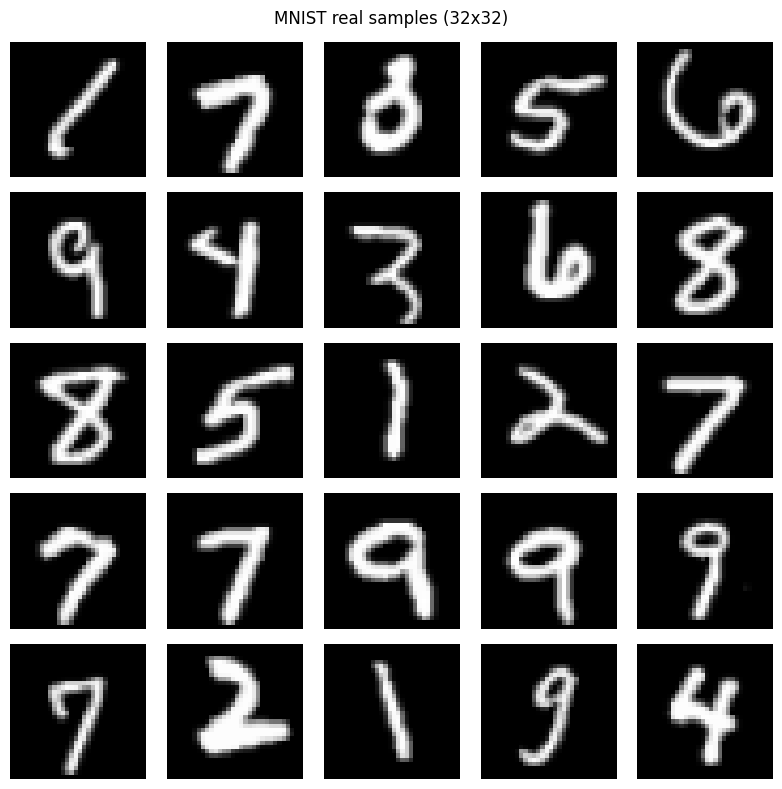

In [7]:
mnist_train_loader, mnist_test_loader, mnist_channels, mnist_image_size, _ = build_loaders(
    dataset_name='mnist',
    batch_size=128,
    train_limit=30000,
    test_limit=5000,
)

x_mnist, _ = next(iter(mnist_train_loader))
show_image_grid(x_mnist, channels=mnist_channels, title='MNIST real samples (32x32)', n_show=25)

Train MNIST DCGAN and save checkpoint.

Goal: instantiate the two models, run training, and persist weights for inference.


Epoch 1/20:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 01/20 | D loss: 0.3079 | G loss: 4.5476


Epoch 2/20:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 02/20 | D loss: 0.3293 | G loss: 3.2633


Epoch 3/20:   0%|          | 0/235 [00:00<?, ?it/s]

...

Epoch 18/20 | D loss: 0.3367 | G loss: 3.2862


Epoch 19/20:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 19/20 | D loss: 0.0770 | G loss: 4.1340


Epoch 20/20:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 20/20 | D loss: 0.7094 | G loss: 2.9931


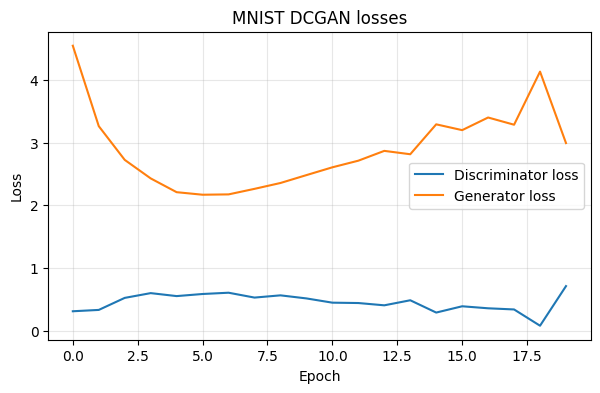

Saved checkpoint to runs\dcgan\mnist_dcgan.pt


In [8]:
# TODO START
mnist_latent_dim = 100
mnist_epochs = 20
mnist_lr = 2e-4
mnist_ckpt = Path('runs/dcgan/mnist_dcgan.pt')

mnist_generator = DCGenerator(mnist_latent_dim, mnist_channels).to(device)
mnist_discriminator = DCDiscriminator(mnist_channels).to(device)
# TODO END

if mnist_generator is None or mnist_discriminator is None:
    raise NotImplementedError('Instantiate MNIST DCGAN models inside TODO block.')

# TODO START
# Recommended: initialize DCGAN weights
mnist_generator.apply(init_dcgan_weights)
mnist_discriminator.apply(init_dcgan_weights)
# TODO END

mnist_history = train_gan(
    generator=mnist_generator,
    discriminator=mnist_discriminator,
    loader=mnist_train_loader,
    latent_dim=mnist_latent_dim,
    epochs=mnist_epochs,
    lr=mnist_lr,
)

plot_gan_losses(mnist_history, title='MNIST DCGAN losses')

save_checkpoint(
    generator=mnist_generator,
    discriminator=mnist_discriminator,
    history=mnist_history,
    checkpoint_path=mnist_ckpt,
    latent_dim=mnist_latent_dim,
    channels=mnist_channels,
    image_size=mnist_image_size,
)

MNIST inference after training.

Goal: load generator checkpoint, render random samples, and render latent interpolation.


In [9]:
@torch.no_grad()
def run_inference(generator, latent_dim, channels, n_samples=25, seed=123, title='Generator inference'):
    # 1) set torch seed
    torch.manual_seed(seed)
    # 2) sample z
    z = torch.randn(n_samples, latent_dim, device=device)
    # 3) generate fake images
    fake = generator(z)

    show_image_grid(fake, channels=channels, title=title, n_show=n_samples)


@torch.no_grad()
def latent_walk(generator, latent_dim, channels, steps=10, title='Latent interpolation'):
    # 1) sample z0 and z1
    z0 = torch.randn(1, latent_dim, device=device)
    z1 = torch.randn(1, latent_dim, device=device)
    # 2) interpolate with alpha in [0, 1]
    alphas = torch.linspace(0, 1, steps, device=device)
    
    # Generate interpolation points
    z_interp = []
    for alpha in alphas:
        z = (1 - alpha) * z0 + alpha * z1
        z_interp.append(z)
    
    z_interp = torch.cat(z_interp, dim=0)
    
    # 3) generate fake images
    fake = generator(z_interp)

    show_image_grid(fake, channels=channels, title=title, n_show=steps)


C:\Users\alexa\AppData\Local\Temp\ipykernel_23768\3392883079.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location=device)


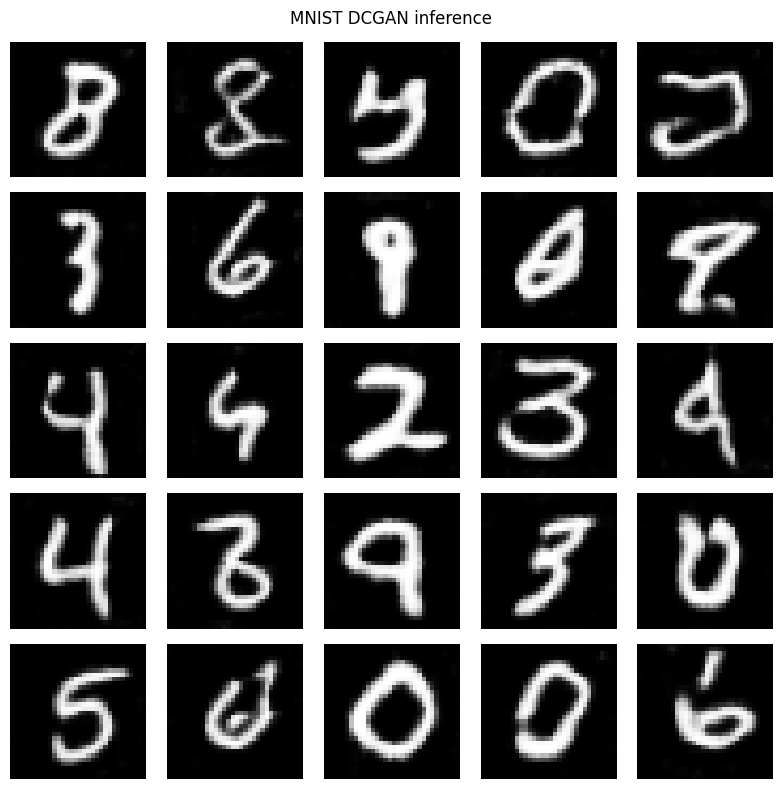

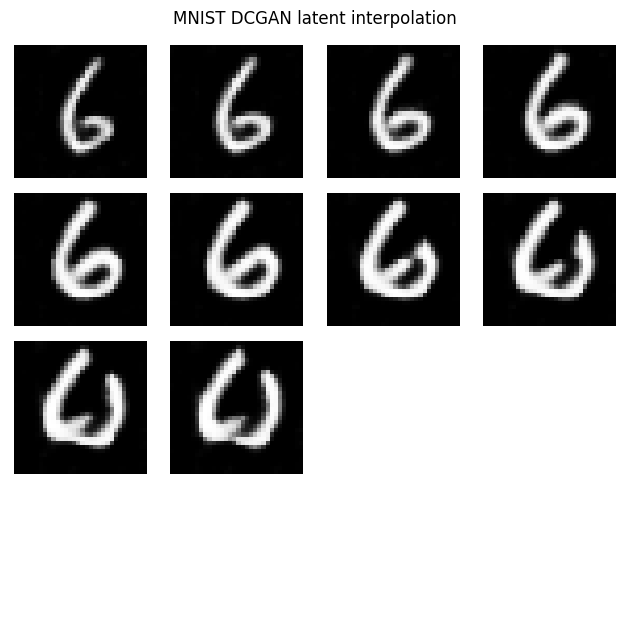

In [10]:
# TODO START
mnist_gen_infer, mnist_cfg, _ = load_dcgan_generator_for_inference(mnist_ckpt)
# TODO END


# TODO START

# Call run_inference(...) and latent_walk(...)
run_inference(
    generator=mnist_gen_infer,
    latent_dim=mnist_cfg['latent_dim'],
    channels=mnist_cfg['channels'],
    n_samples=25,
    seed=123,
    title='MNIST DCGAN inference',
)
latent_walk(
    generator=mnist_gen_infer,
    latent_dim=mnist_cfg['latent_dim'],
    channels=mnist_cfg['channels'],
    steps=10,
    title='MNIST DCGAN latent interpolation',
)
# TODO END

## 2 - CIFAR-10 DCGAN: train and run inference
Repeat the same DCGAN pipeline on CIFAR-10.

Files already downloaded and verified
Files already downloaded and verified


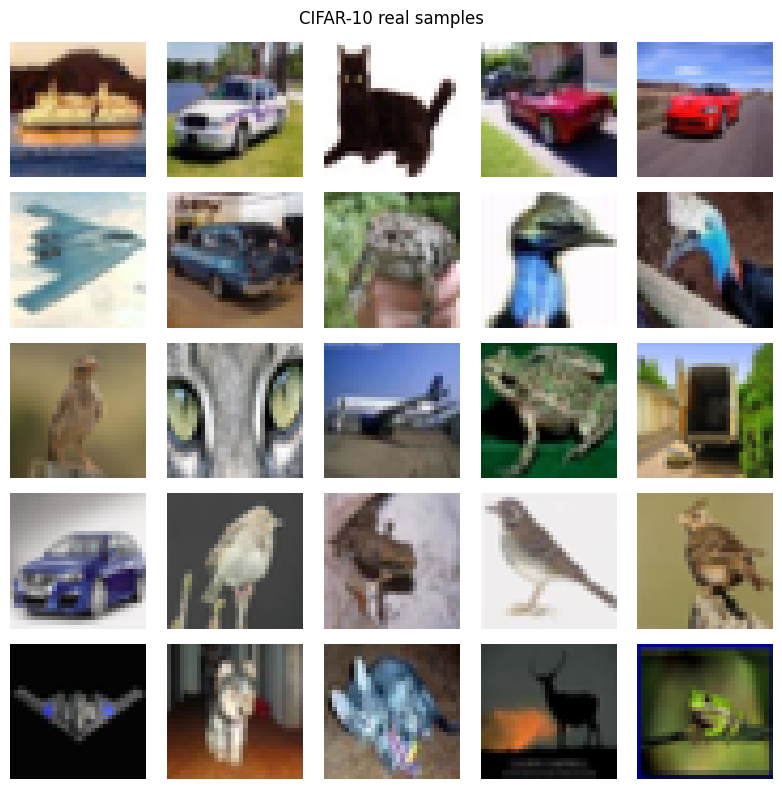

Example labels: ['ship', 'automobile', 'cat', 'automobile', 'automobile', 'airplane', 'automobile', 'frog', 'bird', 'bird']


In [11]:
cifar_train_loader, cifar_test_loader, cifar_channels, cifar_image_size, cifar_class_names = build_loaders(
    dataset_name='cifar10',
    batch_size=128,
    train_limit=30000,
    test_limit=5000,
)

x_cifar, y_cifar = next(iter(cifar_train_loader))
show_image_grid(x_cifar, channels=cifar_channels, title='CIFAR-10 real samples', n_show=25)
print('Example labels:', [cifar_class_names[i] for i in y_cifar[:10].tolist()])

Train CIFAR-10 DCGAN and save checkpoint.

Goal: repeat the same DCGAN training/inference pipeline with CIFAR-10 settings.


Epoch 1/30:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 01/30 | D loss: 0.3787 | G loss: 5.2465


Epoch 2/30:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 02/30 | D loss: 0.5306 | G loss: 4.1105


Epoch 3/30:   0%|          | 0/235 [00:00<?, ?it/s]

...

Epoch 28/30 | D loss: 0.7202 | G loss: 2.1394


Epoch 29/30:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 29/30 | D loss: 0.7354 | G loss: 2.1110


Epoch 30/30:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 30/30 | D loss: 0.7192 | G loss: 2.1529


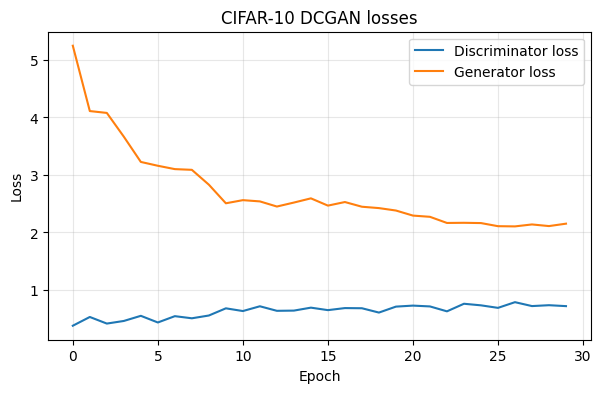

Saved checkpoint to runs\dcgan\cifar10_dcgan.pt


In [12]:
# CIFAR-10 DCGAN Training Configuration
cifar_latent_dim = 100
cifar_epochs = 30
cifar_lr = 2e-4
cifar_ckpt = Path('runs/dcgan/cifar10_dcgan.pt')

cifar_generator = DCGenerator(latent_dim=cifar_latent_dim, image_channels=cifar_channels).to(device)
cifar_discriminator = DCDiscriminator(image_channels=cifar_channels).to(device)

# Recommended: initialize DCGAN weights
cifar_generator.apply(init_dcgan_weights)
cifar_discriminator.apply(init_dcgan_weights)

cifar_history = train_gan(
    generator=cifar_generator,
    discriminator=cifar_discriminator,
    loader=cifar_train_loader,
    latent_dim=cifar_latent_dim,
    epochs=cifar_epochs,
    lr=cifar_lr,
)

plot_gan_losses(cifar_history, title='CIFAR-10 DCGAN losses')

save_checkpoint(
    generator=cifar_generator,
    discriminator=cifar_discriminator,
    history=cifar_history,
    checkpoint_path=cifar_ckpt,
    latent_dim=cifar_latent_dim,
    channels=cifar_channels,
    image_size=cifar_image_size,
)


CIFAR-10 inference after training.

Goal: load generator checkpoint, render random samples, and render latent interpolation.


C:\Users\alexa\AppData\Local\Temp\ipykernel_23768\3392883079.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location=device)


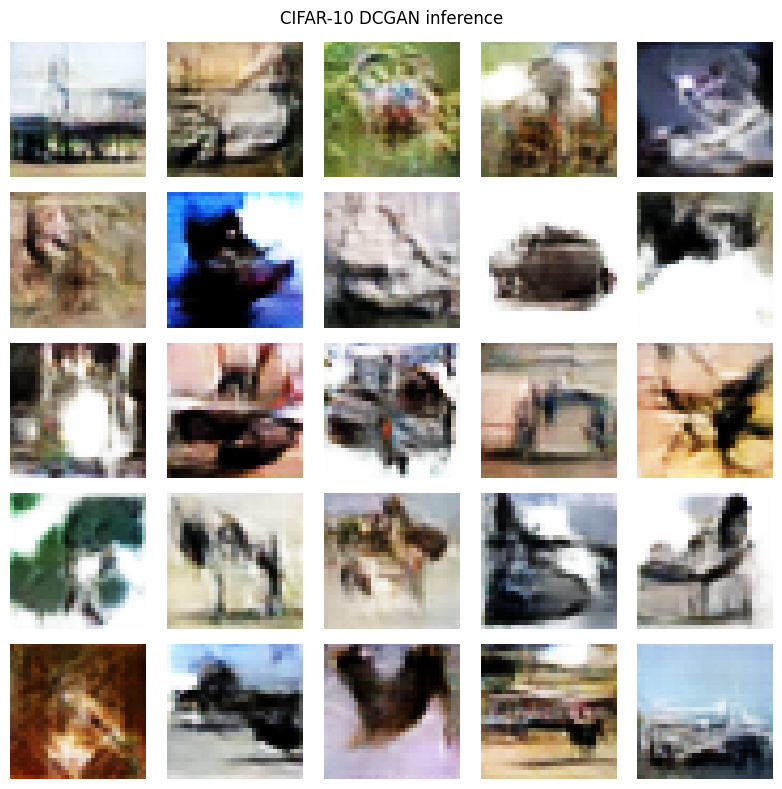

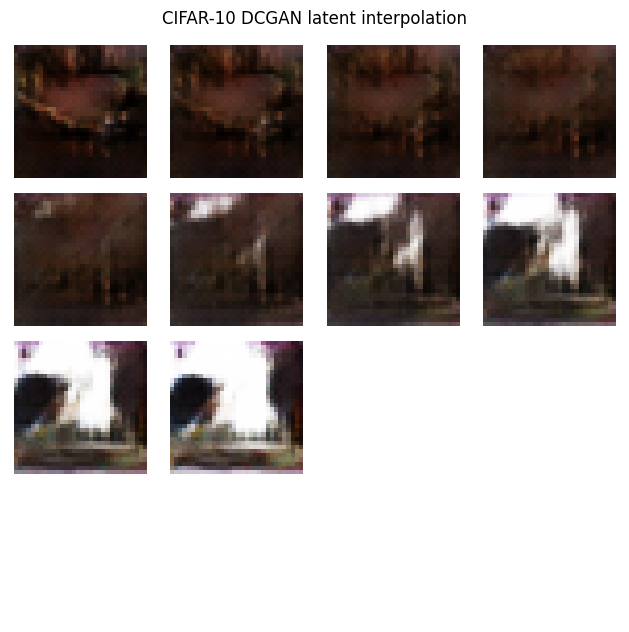

In [13]:
# CIFAR-10 Inference Setup
cifar_gen_infer, cifar_cfg, cifar_hist = load_dcgan_generator_for_inference(cifar_ckpt)

# Call run_inference(...) and latent_walk(...)
run_inference(
    generator=cifar_gen_infer,
    latent_dim=cifar_cfg['latent_dim'],
    channels=cifar_cfg['channels'],
    n_samples=25,
    seed=123,
    title='CIFAR-10 DCGAN inference',
)

latent_walk(
    generator=cifar_gen_infer,
    latent_dim=cifar_cfg['latent_dim'],
    channels=cifar_cfg['channels'],
    steps=10,
    title='CIFAR-10 DCGAN latent interpolation',
)


## Final reflection
1. What differences did you observe between MNIST DCGAN and CIFAR-10 DCGAN stability?
2. Did weight initialization and training length change the sample quality significantly?
3. Which visual cue best indicates early mode collapse in your generated grids?
4. What is the first single hyperparameter you would tune next, and why?


Answers: